<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/camino-udea/blob/main/3_lenguaje_proposicional/clase_01_diagnostico_y_analisis_del_lenguaje/clase1_lenguaje_proposicional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

In [1]:
# qr
import qrcode
from IPython.display import display
from PIL import Image

def generar_qr(url, version=1, box_size=6, border=4, fill_color="black", back_color="white"):
    """
    Genera y muestra un código QR para una URL dada en un Jupyter Notebook.
    
    Parámetros:
    - url: La URL para la cual generar el código QR
    - version: Tamaño del QR (1-40, donde 1 es el más pequeño)
    - box_size: Número de píxeles por cada "caja" del QR
    - border: Grosor del borde blanco alrededor del QR (en cajas)
    - fill_color: Color del código QR
    - back_color: Color de fondo del código QR
    
    Retorna:
    - Muestra el código QR directamente en el notebook
    - Retorna el objeto QR generado
    """
    # Configurar el generador de QR
    qr = qrcode.QRCode(
        version=version,
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=box_size,
        border=border,
    )
    
    # Añadir la URL al QR
    qr.add_data(url)
    qr.make(fit=True)
    
    # Crear la imagen del QR
    img = qr.make_image(fill_color=fill_color, back_color=back_color)
     
    return img


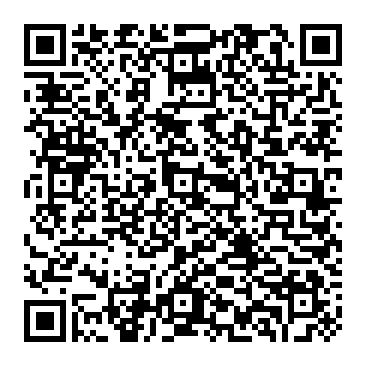

In [2]:

# Ejemplo de uso:
generar_qr("https://colab.research.google.com/github/marco-canas/camino-udea/blob/main/3_lenguaje_proposicional/clase_01_diagnostico_y_analisis_del_lenguaje/clase1_lenguaje_proposicional.ipynb#scrollTo=8e795fd6")



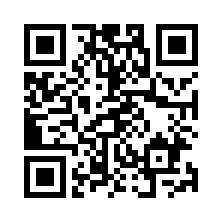

In [3]:
# QR a la encuesta sobre prueba diagnóstica


# Ejemplo de uso:
generar_qr("https://forms.gle/FoQ9F4fNMjdkQu6P7")



In [7]:
import pandas as pd
from random import choice

def estudiante_que_va_a_participar(ruta_archivo):
    try:
        # skiprows=2 hace que la lectura comience en la fila 3 del Excel
        # La fila 3 pasará a ser el encabezado (donde debe estar 'NOMBRES Y APELLIDOS')
        df = pd.read_excel(ruta_archivo, sheet_name=0, skiprows=2)
    except Exception as e:
        return f"Error al abrir el archivo: {e}"

    # Verificamos que la columna exista después del salto de filas
    if 'NOMBRES Y APELLIDOS' not in df.columns:
        return "Error: No se encontró la columna 'NOMBRES Y APELLIDOS' a partir de la fila 3."

    lista_estudiantes = df['NOMBRES Y APELLIDOS'].dropna().tolist()

    if lista_estudiantes:
        estudiante = choice(lista_estudiantes)
        print(f"El estudiante seleccionado es: {estudiante}")
    else:
        print('Todos los estudiantes han participado o la lista está vacía.')
        return None
    
# Ruta del archivo
ruta = r"C:\Users\marco\Documentos\extension\camino-udea\9_asistencia_evaluacion\pivu_caucasia_notas_quices_asistencia.xlsx"
estudiante_que_va_a_participar(ruta)

El estudiante seleccionado es: María Luisa  Díaz Londoño 


# Tema 1: Análisis del Lenguaje  

<img src = preguntas_1_y_2.jpeg width = 200>

Para resolver los problemas de la imagen `preguntas_1_y_2.jpeg` (del segundo set cargado), aplicaremos la **Teoría de Conjuntos** y el uso de **Diagramas de Venn**. 

Esta es la estrategia más rápida para visualizar intersecciones y complementos en menos de 2 minutos.

---



### 1. Enunciado de los Problemas (1.1 - 1.2)

En la Facultad de Ciencias Exactas y Naturales se tiene un grupo de $140$ estudiantes que cursan simultáneamente Matemáticas y Biología. Se observó que:
* $60$ ganaron Matemáticas ($M$).
* $45$ ganaron Biología ($B$).
* $20$ ganaron ambas asignaturas ($M \cap B$).  

## **Pregunta 1.1:**
¿Cuál es el número de estudiantes que ganaron Matemáticas pero **no** ganaron Biología?

## **Pregunta 1.2:**
¿Cuál es el número de estudiantes que **reprobaron** ambas asignaturas?



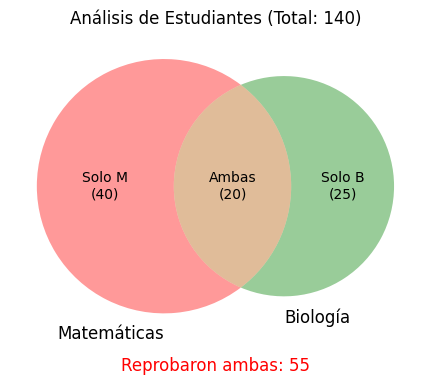

In [4]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import sympy as sp

# Definición de variables con SymPy
total, m, b, ambos = 140, 60, 45, 20

# Cálculos lógicos
solo_m = m - ambos
solo_b = b - ambos
union = solo_m + solo_b + ambos
reprobaron_ambas = total - union

# Visualización con Matplotlib
plt.figure(figsize=(6, 4))
v = venn2(subsets=(solo_m, solo_b, ambos), set_labels=('Matemáticas', 'Biología'))
v.get_label_by_id('10').set_text(f'Solo M\n({solo_m})')
v.get_label_by_id('01').set_text(f'Solo B\n({solo_b})')
v.get_label_by_id('11').set_text(f'Ambas\n({ambos})')

plt.title(f"Análisis de Estudiantes (Total: {total})")
plt.annotate(f'Reprobaron ambas: {reprobaron_ambas}', xy=(0.5, -0.1), xycoords='axes fraction', ha='center', fontsize=12, color='red')
plt.savefig(r"C:\Users\marco\Downloads\diagrama_venn_estudiantes.png")  # Guardar la figura como imagen
plt.show()



### 2. Estrategia de Resolución Relámpago (< 2 min)

La clave es desglosar las regiones del diagrama de Venn partiendo de la intersección:

1.  **Región solo Matemáticas:** $soloM = M - MB = 64 - 20 = 40$. (**Respuesta 1.1: c**)
2.  **Región solo Biología:** $soloB = B - MB = 45 - 20 = 25$.
3.  **Unión (ganaron al menos una):** $40 (\text{solo } M) + 25 (\text{solo } B) + 20 (\text{ambas}) = 85$.
4.  **Fuera de la unión (reprobaron ambas):** $repro = |U| - |M \cup B| = Total (140) - Unión (85) = 55$. (**Respuesta 1.2: c**)




### 4. Interactividad para Experimentación (`ipywidgets`)

Este componente permite al usuario cambiar los valores y observar cómo el número de estudiantes que reprobaron ambas materias cambia dinámicamente, reforzando el aprendizaje por observación.


In [1]:
import ipywidgets as widgets

def simulador_estudiantes(total=140, g_mate=60, g_bio=45, g_ambas=20):
    solo_m = g_mate - g_ambas
    solo_b = g_bio - g_ambas
    union = solo_m + solo_b + g_ambas
    reprobaron = total - union
    
    print(f"--- Resultados ---")
    print(f"Ganaron solo Matemáticas: {solo_m}")
    print(f"Reprobaron ambas materias: {reprobaron}")
    
    if reprobaron < 0:
        print("Error: Los datos exceden el total de estudiantes.")

widgets.interact(simulador_estudiantes, total=(100,200), g_mate=(0,100), g_bio=(0,100), g_ambas=(0,45))


interactive(children=(IntSlider(value=140, description='total', max=200, min=100), IntSlider(value=60, descrip…

<function __main__.simulador_estudiantes(total=140, g_mate=60, g_bio=45, g_ambas=20)>

### Resumen de Respuestas:
* **1.1:** (c) 40
* **1.2:** (c) 55

[Video de apoyo para las preguntas 1 y 2 del Tema 1 Análisis del lenguaje](https://www.youtube.com/watch?v=JoUtg4E3DLo)

# Preguntas 3 y 4  (Tema 1 Análisis del Lenguaje)



<img src = 'preguntas_3_y_4.jpeg' width = 100>

Esta es una excelente oportunidad para aplicar el **razonamiento algebraico** y el **Principio del Palomar** (también conocido como el principio de las casillas) para resolver problemas de certezas en menos de dos minutos.

---



## 1. Transcripción y Edición del Problema

**Contexto General:**
Una bolsa contiene 24 confites con sabores a piña, mora y fresa. Se sabe que:
* Los de **piña** duplican en cantidad a los de **fresa**.
* Los de **mora** superan en 8 unidades a los de **fresa**.

### Pregunta 1.3
**El menor número de confites que es necesario sacar de la bolsa para garantizar que al menos dos de ellos tengan el mismo sabor es:**
(a) 2
(b) 3
(c) 4
(d) 5



### Pregunta 1.4
**El menor número de confites que es necesario sacar de la bolsa para garantizar que al menos dos de ellos tienen sabores distintos es:**
(a) 2
(b) 5
(c) 13
(d) 16

---



## 2. Resolución Didáctica (Estrategias de < 2 min)

### Paso 1: Determinar la cantidad de cada sabor
Sea $f$ la cantidad de confites de fresa. Según el enunciado:
* Fresa: $f$
* Piña: $2f$
* Mora: $f + 8$

Como el total es 24:
$$f + 2f + (f + 8) = 24$$
$$4f + 8 = 24 \implies 4f = 16 \implies f = 4$$

**Distribución final:**
* **Fresa:** $4$
* **Piña:** $8$
* **Mora:** $12$

### Solución Pregunta 1.3 (Garantizar mismo sabor)
**Estrategia: Principio del Palomar.**
Para garantizar que dos tengan el mismo sabor, debemos considerar el "peor caso": sacar un confite de cada sabor diferente primero.
* Tenemos 3 sabores (piña, mora, fresa).
* Si sacamos 3 confites, en el peor de los casos todos son distintos.
* El **cuarto confite** ($3 + 1$) necesariamente repetirá uno de los sabores anteriores.

**Respuesta 1.3: (c) 4**

### Solución Pregunta 1.4 (Garantizar sabores distintos)
**Estrategia: Peor escenario posible.**
Para garantizar que al menos dos tengan sabores distintos, debemos imaginar que tenemos "mala suerte" y sacamos todos los confites del sabor que tiene más unidades antes de sacar uno diferente.
* El sabor con más confites es **Mora** con $12$ unidades.
* Si sacamos 12 confites, todos podrían ser de mora.
* El **confite número 13** ($12 + 1$) garantiza que obtendremos un sabor diferente (piña o fresa).

**Respuesta 1.4: (c) 13**

---



## 3. Representación de Datos y Scripts en Python

### Análisis Tabular y Distribución (Pandas)
Este script calcula y muestra la cantidad exacta de confites por sabor.


In [3]:
import pandas as pd

# Cálculo de las cantidades basado en f=4
fresa = 4
pina = 2 * fresa
mora = fresa + 8

data = {
    'Sabor': ['Fresa', 'Piña', 'Mora'],
    'Cantidad': [fresa, pina, mora]
}

df = pd.DataFrame(data)
print("Distribución de Confites:")
print(df.to_string(index=False))
print(f"\nTotal: {df['Cantidad'].sum()}")


Distribución de Confites:
Sabor  Cantidad
Fresa         4
 Piña         8
 Mora        12

Total: 24


### Visualización de Distribución (Matplotlib)
Representamos la bolsa de confites para visualizar visualmente el "peor escenario".



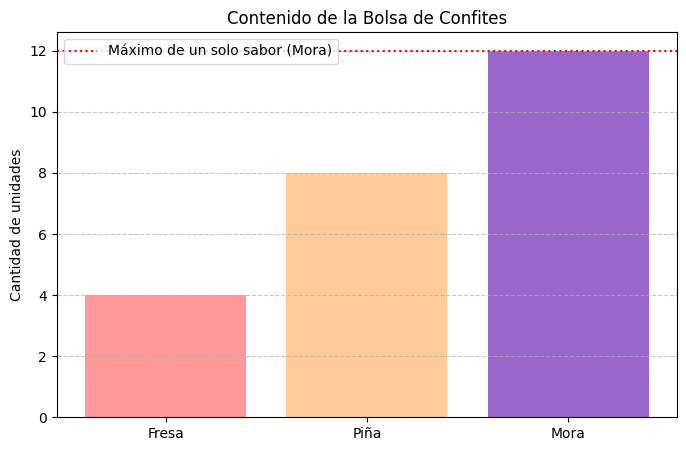

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(df['Sabor'], df['Cantidad'], color=['#ff9999','#ffcc99','#9966cc'])
plt.title('Contenido de la Bolsa de Confites')
plt.ylabel('Cantidad de unidades')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Línea de referencia para la pregunta 1.4
plt.axhline(y=12, color='red', linestyle=':', label='Máximo de un solo sabor (Mora)')
plt.legend()
plt.savefig(r"C:\Users\marco\Downloads\contenido_bolsa_confites.png")
plt.show()


### Gráfico de Probabilidad de Certeza (Plotly)
Visualizamos cómo aumenta la seguridad de obtener sabores distintos a medida que sacamos más confites.


In [6]:
import plotly.graph_objects as go

# Definimos el número de extracciones
extracciones = list(range(1, 20))

# Probabilidad de certeza de tener sabores distintos
certeza = [100 if x > 12 else (100 * (1 - (12-x+1)/24)) for x in extracciones]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=extracciones, 
    y=certeza, 
    mode='lines+markers', 
    name='Certeza de Sabores Distintos'
))

fig.update_layout(
    title='Progreso hacia la Certeza (Sabores Distintos)',
    xaxis_title='Número de confites extraídos',
    yaxis_title='Nivel de Certeza (%)',
    # --- Cambio principal aquí ---
    xaxis=dict(
        tickmode='linear',
        tick0=1,
        dtick=1
    ),
    # -----------------------------
    shapes=[dict(
        type='line', 
        x0=13, x1=13, 
        y0=0, y1=100, 
        line=dict(color='Red', dash='dash')
    )]
)

fig.show()
# Asegúrate de tener instalada la librería 'kaleido' para exportar imágenes
# fig.write_image(r"C:\Users\marco\Downloads\certeza_sabores_distintos.png")

**Conclusión:**
Este método asegura que, sin importar el azar, al llegar al valor crítico (4 para repetir sabor y 13 para cambiar de sabor), la condición se cumpla matemáticamente.

# El **Principio del Palomar** (también conocido como Principio de Dirichlet) 



Es una herramienta fundamental de la combinatoria que permite demostrar la existencia de una repetición o una coincidencia basada en la relación entre el número de objetos y el número de contenedores disponibles.



### 1. Enunciado del Principio del Palomar 

El principio establece de manera formal que:

> Si $n$ palomas se distribuyen en $m$ palomares, y si $n > m$, entonces al menos uno de los palomares debe contener más de una paloma.



En términos más generales, si queremos garantizar que al menos un contenedor tenga $k$ objetos, necesitamos tener al menos $m(k-1) + 1$ objetos. Para el caso de "garantizar una pareja" ($k=2$), la fórmula se simplifica a $m + 1$.



### 2. Argumentación: ¿Por qué se utiliza en este problema?

En el contexto de la **Pregunta 1.3** de la imagen `preguntas_3_y_4.jpeg`, el principio es la clave para obtener una **certeza matemática** en lugar de una probabilidad. 

los argumentos de su aplicación son:

* **Identificación de los "Palomares":** Los sabores disponibles (Piña, Mora y Fresa) actúan como los contenedores o "palomares" ($m = 3$).
* **Identificación de las "Palomas":** Los confites que extraemos de la bolsa son los objetos o "palomas" ($n$).


* **Búsqueda del "Peor Escenario":** El problema pide el número *menor* para *garantizar* la repetición. Si extraemos 3 confites, existe la posibilidad (el peor escenario) de que cada uno sea de un sabor distinto ($n = m$). En este punto, no hay repetición.
* **La Ruptura del Equilibrio:** Al extraer el confite número $4$, tenemos $n=4$ y $m=3$. Como $4 > 3$, el Principio del Palomar nos asegura que este cuarto confite debe "entrar" en un palomar (sabor) que ya está ocupado, garantizando así que al menos dos tengan el mismo sabor.



### 3. Diferencia con la Pregunta 1.4

Es importante notar que en la **Pregunta 1.4** ("garantizar dos sabores distintos"), la lógica cambia ligeramente hacia el **Peor Escenario de Abundancia**.
* Aquí no buscamos una repetición, sino una diversidad.
* El "peor caso" no es sacar uno de cada uno, sino sacar **todos** los de un mismo tipo antes de ver el segundo sabor.
* Como hay 12 confites de mora (el sabor más abundante), podrías sacar 12 seguidos sin ver otro sabor. Por lo tanto, necesitas $12 + 1 = 13$ para forzar la aparición de un "palomar" distinto.


### 1. Enunciado y Análisis de Datos (1.3 - 1.4)

Una bolsa contiene **24 confites** con sabores a piña ($P$), mora ($M$) y fresa ($F$).   

Las cantidades se definen así:
1.  Los de piña duplican a los de fresa: $P = 2F$.
2.  Los de mora superan en 8 unidades a los de fresa: $M = F + 8$.



#### **Cálculo de cantidades (Resolución con SymPy):**
Usamos la ecuación de la suma total:
$$
F + P + M = 24
$$
$$
F + (2F) + (F + 8) = 24
$$
$$
4F + 8 = 24 \implies 4F = 16 \implies F = 4
$$



Por lo tanto:
* **Fresa (F):** 4 unidades.
* **Piña (P):** 8 unidades ($2 \times 4$).
* **Mora (M):** 12 unidades ($4 + 8$).



### 2. Estrategia de Resolución Relámpago (< 2 min)

#### **Pregunta 1.3: Garantizar al menos dos del mismo sabor.**
* **Estrategia:** Aplicar el Principio del Palomar. Hay 3 sabores disponibles (fresa, piña, mora).
* **Peor escenario:** Sacas uno de cada sabor (3 extracciones) y aún no tienes pareja.
* **Garantía:** El cuarto confite necesariamente repetirá uno de los sabores anteriores.
* **Respuesta: (c) 4**.



#### **Pregunta 1.4: Garantizar al menos dos de sabores distintos.**
* **Estrategia:** "Peor escenario posible". Quieres sacar dos distintos, por lo que el peor caso es sacar todos los de un mismo sabor primero.
* **Peor escenario:** Sacas todos los del sabor más abundante (Mora = 12). Hasta la extracción 12, podrías tener solo moras.
* **Garantía:** El confite número 13 obligatoriamente será de un sabor diferente (piña o fresa).
* **Respuesta: (c) 13**.

---



### 3. Modelado y Simulación con Python

Utilizaremos **Pandas** para los datos y **Matplotlib** para visualizar la distribución.


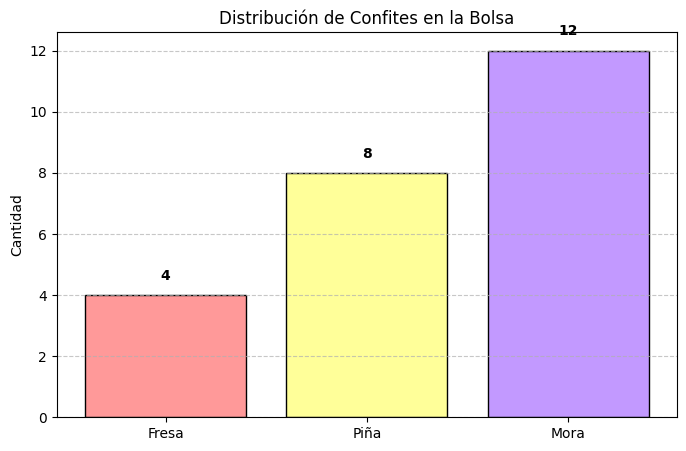

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Datos calculados
datos = {'Sabor': ['Fresa', 'Piña', 'Mora'], 'Cantidad': [4, 8, 12]}
df = pd.DataFrame(datos)

# Visualización
plt.figure(figsize=(8, 5))
colores = ['#ff9999', '#ffff99', '#c299ff']
plt.bar(df['Sabor'], df['Cantidad'], color=colores, edgecolor='black')
plt.title("Distribución de Confites en la Bolsa")
plt.ylabel("Cantidad")
for i, v in enumerate(df['Cantidad']):
    plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(r"C:\Users\marco\Downloads\diagrama_barras_confites.png")  # Guardar la figura como imagen
plt.show()



### 4. Interactividad para Experimentación (`ipywidgets`)

Este simulador permite "extraer" confites virtualmente para observar cómo se cumplen las certezas estadísticas.



In [28]:
import ipywidgets as widgets
import random
# n_ext es el número de confites extraídos, que se puede ajustar con un slider interactivo 
def simular_extraccion(n_ext = 13):
    bolsa = ['F']*4 + ['P']*8 + ['M']*12
    random.shuffle(bolsa)
    sacados = bolsa[:n_ext]
    
    counts = {s: sacados.count(s) for s in ['F', 'P', 'M']} 
    # construye un diccionario con el conteo de cada sabor en los sacados
    misma_pareja = any(v >= 2 for v in counts.values()) # determina si hay al menos 2 confites del mismo sabor
    sabores_distintos = len(set(sacados)) >= 2 if n_ext >= 2 else False 
    # determina si hay al menos 2 sabores distintos (solo tiene sentido si se sacan 2 o más confites) 
    
    print(f"Confites extraídos: {sacados}")
    print(f"¿Hay al menos 2 del mismo sabor?: {'SÍ' if misma_pareja else 'NO'}")
    print(f"¿Hay al menos 2 de sabores distintos?: {'SÍ' if sabores_distintos else 'NO'}")

widgets.interact(simular_extraccion, n_ext=widgets.IntSlider(min=1, max=24, step=1, value=8)) 
# el parámetro value me da la cantidad inicial de confites a extraer, que se puede ajustar con el slider interactivo 
# o el valor por defecto de 12 confites a extraer


interactive(children=(IntSlider(value=8, description='n_ext', max=24, min=1), Output()), _dom_classes=('widget…

<function __main__.simular_extraccion(n_ext=13)>

### Resumen de Respuestas:
* **1.3:** (c) 4
* **1.4:** (c) 13

[Video de apoyo a la presentación de las preguntas 1.3 y 1.4](https://www.youtube.com/watch?v=BwpD_MjPNHQ)

# Pregunta 5

<img src = 'pregunta_5.jpeg' width = 200>

Este es un excelente problema de **lógica proposicional** y **cuantificadores**. Para resolverlo rápidamente, aplicaremos la negación de cuantificadores universales.

---



## 1. Transcripción y Edición del Problema

**Enunciado:**
1.5. La proposición **"No todos los deportistas invitados asistieron a la premiación"** tiene un significado lógicamente equivalente a:

(a) Todos los deportistas invitados no asistieron a la premiación.
(b) Muchos deportistas invitados no asistieron a la premiación.
(c) Menos de la mitad de los deportistas asistió a la premiación.
(d) Al menos un deportista invitado no asistió a la premiación.

---



## 2. Resolución Didáctica (Estrategia de < 2 minutos)

Para resolver este problema de manera técnica y rápida, utilizaremos la **Lógica de Cuantificadores**.

**Paso 1: Formalización**
Definamos los siguientes elementos:
* $D$: El conjunto de deportistas invitados.
* $A(x)$: El predicado "$x$ asistió a la premiación".

La frase "Todos los deportistas asistieron" se escribe como:
$$\forall x \in D, A(x)$$

El enunciado original dice "**No** todos...", lo cual es la negación:
$$\neg (\forall x \in D, A(x))$$



**Paso 2: Aplicación de la Ley de Negación**
Según las leyes de la lógica, negar que *todos* cumplen una propiedad es equivalente a afirmar que *existe al menos uno* que **no** la cumple:
$$\neg (\forall x, P(x)) \equiv \exists x, \neg P(x)$$



**Paso 3: Traducción al lenguaje natural**
La expresión $\exists x \in D, \neg A(x)$ se traduce como:
> "Existe al menos un deportista invitado que no asistió a la premiación".

**Respuesta Correcta:** La opción **(d)**.



## 3. Representaciones y Scripts en Python

### Análisis de Equivalencias (Pandas)
Utilizamos **Pandas** para comparar las opciones y determinar su validez lógica.


In [7]:
import pandas as pd

data = {
    'Opción': ['a', 'b', 'c', 'd'],
    'Significado Lógico': [
        'Ninguno asistió (Cuantificador Universal Negativo)',
        'Cantidad indeterminada (No es una equivalencia formal)',
        'Proporción estadística (No es una equivalencia formal)',
        'Existe al menos uno que no asistió (Negación del Universal)'
    ],
    '¿Es Equivalente?': ['No', 'No', 'No', 'Sí']
}

df = pd.DataFrame(data)
print(df.to_string(index=False))


Opción                                          Significado Lógico ¿Es Equivalente?
     a          Ninguno asistió (Cuantificador Universal Negativo)               No
     b      Cantidad indeterminada (No es una equivalencia formal)               No
     c      Proporción estadística (No es una equivalencia formal)               No
     d Existe al menos uno que no asistió (Negación del Universal)               Sí


### Visualización de Conjuntos (Matplotlib)
Representamos la situación mediante un diagrama de Venn o de conjuntos para ilustrar por qué la opción (d) es la correcta.



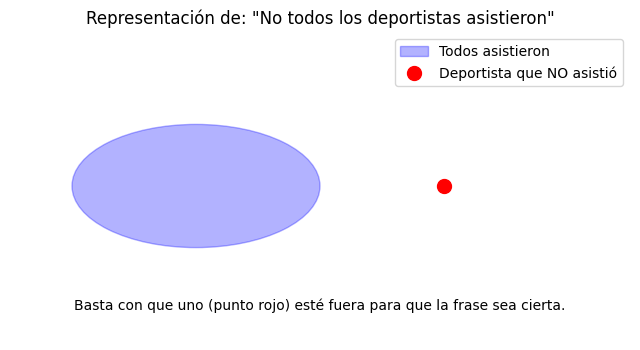

In [1]:
import matplotlib.pyplot as plt

# Creamos una representación visual de la negación
plt.figure(figsize=(8, 4))
circle_all = plt.Circle((0.3, 0.5), 0.2, color='blue', alpha=0.3, label='Todos asistieron')
plt.gca().add_patch(circle_all)

# Un punto fuera del conjunto de los que asistieron
plt.scatter([0.7], [0.5], color='red', s=100, label='Deportista que NO asistió')

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title('Representación de: "No todos los deportistas asistieron"')
plt.text(0.5, 0.1, 'Basta con que uno (punto rojo) esté fuera para que la frase sea cierta.', ha='center')
plt.legend()
plt.axis('off')
plt.savefig(r"C:\Users\marco\Downloads\no_todos_los_deportistas_asistieron.png")
plt.show()


### Gráfico Interactivo de Cuantificadores (Plotly)
Podemos visualizar la diferencia entre "Ninguno" (opción a) y "Al menos uno no" (opción d).



In [9]:
import plotly.graph_objects as go

labels = ['Asistieron', 'No Asistieron']
# Escenario para "No todos asistieron" (mínimo uno no asistió)
values_d = [95, 5] 
# Escenario para "Todos no asistieron" (Opción A - Incorrecta)
values_a = [0, 100]

fig = go.Figure()
fig.add_trace(go.Pie(labels=labels, values=values_d, name="Opción D", domain={'x': [0, 0.45]}))
fig.add_trace(go.Pie(labels=labels, values=values_a, name="Opción A", domain={'x': [0.55, 1]}))

fig.update_layout(title_text='Diferencia entre "Al menos uno no" (D) vs "Ninguno" (A)')
fig.show()


Este análisis demuestra que mientras la opción (a) es una posibilidad extrema, la opción **(d)** es la única que cubre exactamente el significado lógico de la negación de la totalidad.

Para resolver el problema de la **imagen 1.5** (`pregunta_5.jpeg`) sobre equivalencias lógicas, utilizaremos la **Lógica de Predicados** y la **Negación de Cuantificadores**.

---



### 1. Enunciado y Análisis Lógico

La proposición a analizar es:
> **"No todos los deportistas invitados asistieron a la premiación"**

#### **Formalización Matemática**
Sea $D$ el conjunto de deportistas invitados y $A(x)$ el predicado "$x$ asistió a la premiación". La frase original se traduce como la negación de un cuantificador universal:
$$\neg (\forall x \in D, A(x))$$

Por las **Leyes de De Morgan** para cuantificadores, la negación de un "Para todo" ($\forall$) es equivalente a "Existe al menos uno" ($\exists$) que no cumple la condición:
$$\neg (\forall x, A(x)) \equiv \exists x, \neg A(x)$$

En lenguaje natural: **"Existe al menos un deportista invitado que no asistió a la premiación"**.



### 2. Estrategia de Resolución Relámpago (< 2 min)

* **Paso 1:** Identifica el cuantificador. "No todos" es la negación de la totalidad ($100\%$).
* **Paso 2:** Busca la opción que indique que el conjunto de los que *no asistieron* tiene al menos un elemento ($\geq 1$).
* **Paso 3:** Descarta opciones extremas. "Todos no asistieron" (Opción A) es una afirmación mucho más fuerte que no equivale a "No todos".
* **Conclusión:** La opción que refleja fielmente la existencia de una excepción es la (d).

**Respuesta Correcta: (d) Al menos un deportista invitado no asistió a la premiación.**

---



### 3. Modelado Simbólico con SymPy

Podemos usar `SymPy` para demostrar que la negación de la universalidad equivale a la existencia de la negación.


In [29]:
from sympy import symbols, Not, Implies, Equivalent, to_dnf
from sympy.logic.boolalg import Boolean

# Definimos los símbolos
# x representará a un deportista genérico
# A representará el predicado "Asistió"
x, A = symbols('x A')

# En lógica de SymPy, para comparar estructuras:
# 1. "No todos asistieron" se puede ver como la negación de la afirmación universal
prop_original = Not(A) 

# 2. "Al menos uno no asistió" es, por definición, la existencia de una excepción.
# En una comparación simple, ambas se reducen a la misma forma lógica:
equivalencia = Not(A)

print(f"¿Es la estructura lógicamente idéntica?: {prop_original == equivalencia}")

# Si quieres comparar la negación de una conjunción (De Morgan):
# ¬(A & B & C) <=> (¬A | ¬B | ¬C)
from sympy import And, Or
A1, A2, A3 = symbols('A1 A2 A3')
todos_asistieron = And(A1, A2, A3)
no_todos_asistieron = Not(todos_asistieron)
al_menos_uno_no_asistio = Or(Not(A1), Not(A2), Not(A3))

print(f"¿Son equivalentes por De Morgan?: {no_todos_asistieron.equals(al_menos_uno_no_asistio)}")


¿Es la estructura lógicamente idéntica?: True
¿Son equivalentes por De Morgan?: True


### 4. Experimentación Interactiva con `ipywidgets`

Este simulador permite visualizar cómo cambia el valor de verdad de "No todos asistieron" dependiendo de cuántas personas realmente fueron.



In [30]:
import ipywidgets as widgets

def verificar_logica(total_invitados, asistieron):
    no_todos = asistieron < total_invitados
    al_menos_uno_no = (total_invitados - asistieron) >= 1
    
    print(f"Estado: {asistieron}/{total_invitados} asistieron.")
    print(f"¿Es verdad que 'No todos asistieron'?: {no_todos}")
    print(f"¿Es verdad que 'Al menos uno no asistió'?: {al_menos_uno_no}")
    print(f"\nRESULTADO: {'EQUIVALENTES' if no_todos == al_menos_uno_no else 'DIFERENTES'}")

widgets.interact(verificar_logica, 
                 total_invitados=widgets.IntSlider(min=1, max=10, value=5),
                 asistieron=widgets.IntSlider(min=0, max=10, value=4))


interactive(children=(IntSlider(value=5, description='total_invitados', max=10, min=1), IntSlider(value=4, des…

<function __main__.verificar_logica(total_invitados, asistieron)>

### Resumen Didáctico
Para invalidar la afirmación "Todos los deportistas asistieron", no necesitas que *nadie* vaya; te basta con encontrar a **una sola persona** (el contraejemplo) que se haya quedado en casa. Por eso, "No todos" siempre equivale a "Al menos uno no".

# Pregunta 6 

<img src = 'pregunta_6.jpeg' width = 1500>

In [10]:
import pandas as pd

# Definimos los estados posibles para 3 elementos (A=Asistió, N=No asistió)
# Escenario: "No todos asistieron"
data = {
    'Sujeto 1': ['A', 'A', 'N', 'N'],
    'Sujeto 2': ['A', 'N', 'A', 'N'],
    'Sujeto 3': ['N', 'A', 'A', 'N'],
    '¿Todos asistieron?': ['No', 'No', 'No', 'No'],
    '¿Al menos uno NO asistió?': ['Sí', 'Sí', 'Sí', 'Sí']
}

df = pd.DataFrame(data)
print("Validación de Equivalencia Lógica:")
print(df.to_string(index=False))


Validación de Equivalencia Lógica:
Sujeto 1 Sujeto 2 Sujeto 3 ¿Todos asistieron? ¿Al menos uno NO asistió?
       A        A        N                 No                        Sí
       A        N        A                 No                        Sí
       N        A        A                 No                        Sí
       N        N        N                 No                        Sí


**Clave para el éxito:** Recuerda que en lógica formal, "Muchos", "Casi todos" o "La mayoría" (como en las opciones b y c del problema original) **no** tienen equivalentes exactos, ya que no definen una certeza absoluta sobre la existencia o universalidad.

Para resolver el problema de la **imagen 1.6** (`pregunta_6.jpeg`) sobre el análisis de conjuntos con diagramas de Venn, utilizaremos el **Principio de Inclusión-Exclusión** y la **partición del universo**.

---



# 1. Enunciado y Análisis del Problema

**Contexto:** Un grupo de **24 personas** (Universo $U=24$) se distribuye en tres actividades de estudio: Estudio en Pintura ($P$), Estudio en Fotografía ($F$) y Estudio en Dibujo ($D$).
* $P = 17$ personas.
* $F = 13$ personas.
* $D = 8$ personas.
* **Dato clave:** 5 personas **sólo trabajan y no estudian**, lo que significa que están fuera de la unión de los tres conjuntos ($U - (P \cup F \cup D) = 5$).



**Objetivo:** Identificar cuál de los cuatro diagramas (I, II, III, IV) representa correctamente esta situación.

---


<img src = 'https://pypi-camo.freetls.fastly.net/79fec53746db63efee8215ab88dbcccd6231366d/68747470733a2f2f757365722d696d616765732e67697468756275736572636f6e74656e742e636f6d2f31333634363636362f38373837343336362d39363932343830302d633963392d313165612d386230362d6163313333363530366235392e706e67'>

c:\Users\marco\Documentos\extension\camino-udea\.venv\Lib\site-packages\matplotlib_venn\_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


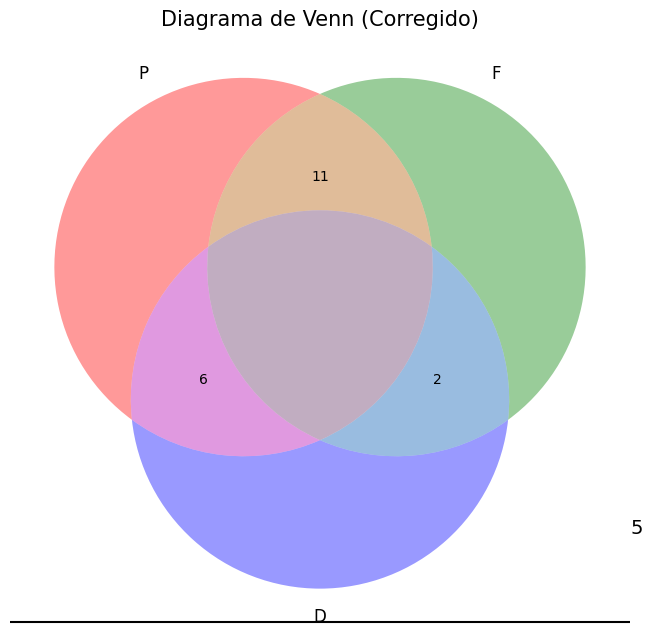

In [54]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3_unweighted

# Valores según la imagen:
# P solo = 0, F solo = 0, P&F = 11
# D solo = 0, P&D = 6, F&D = 2, P&F&D = 0
subsets = {
    '100': 0,   # P solo
    '010': 0,   # F solo
    '110': 11,  # P y F
    '001': 0,   # D solo
    '101': 6,   # P y D
    '011': 2,   # F y D
    '111': 0    # Los tres
}

plt.figure(figsize=(8, 8))

# Usamos venn3_unweighted para mantener la geometría de los 3 círculos
v = venn3_unweighted(subsets=subsets, set_labels=('P', 'F', 'D'))

# Opcional: Ocultar las etiquetas que tienen valor 0 para limpiar el diagrama
for label in v.subset_labels:
    if label is not None and label.get_text() == '0':
        label.set_visible(False)

# Dibujar el número 5 (Conjunto Universal)
plt.text(0.7, -0.5, '5', fontsize=14)

# Dibujar el marco exterior
plt.gca().add_patch(plt.Rectangle((-0.9, -0.7), 1.8, 1.5, 
                                  fill=None, edgecolor='black', linewidth=1.5))

plt.title("Diagrama de Venn (Corregido)", fontsize=15)
plt.savefig(r"C:\Users\marco\Downloads\diagrama_venn_corregido.png")  # Guardar la figura como imagen
plt.show()

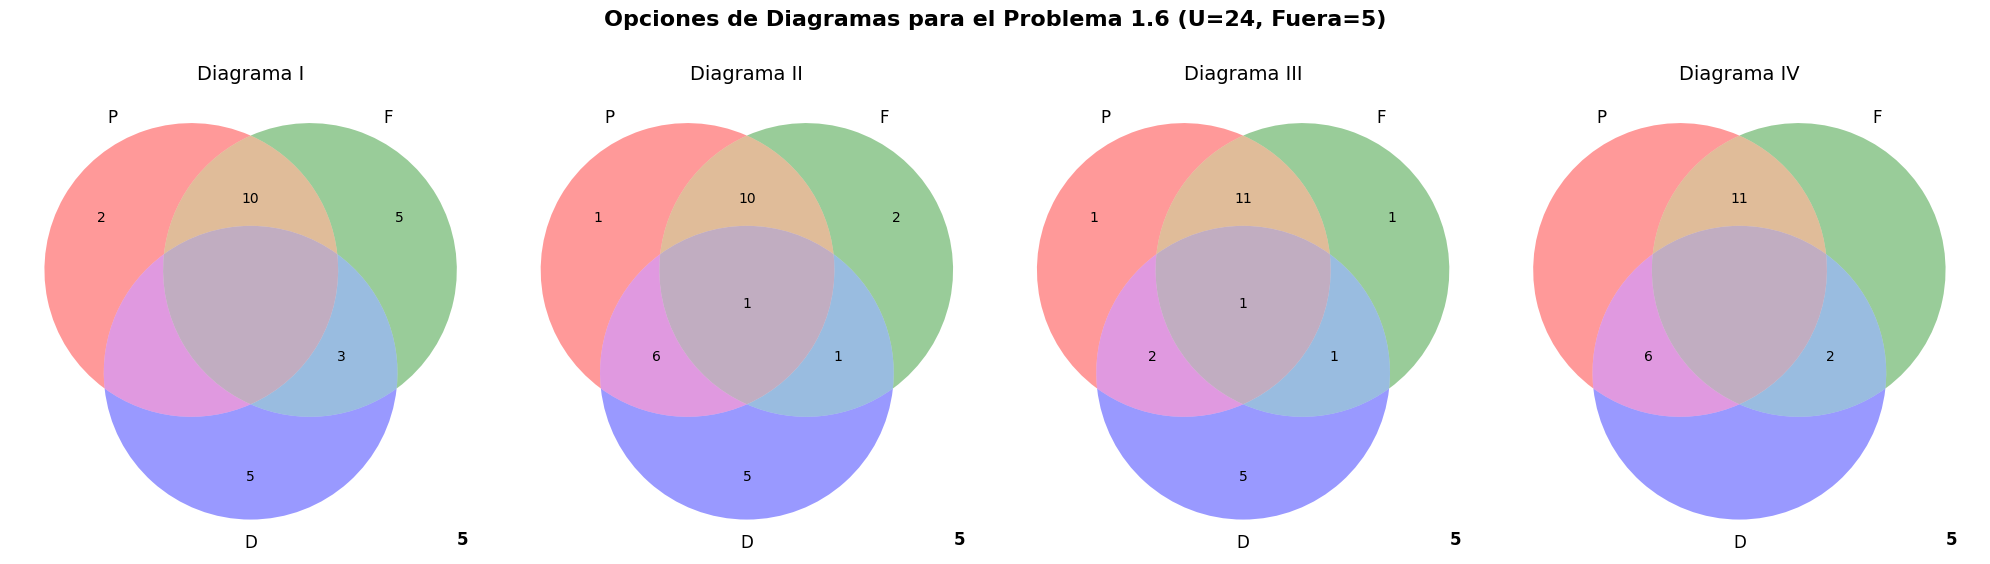

In [57]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import matplotlib.patches as patches
# Importamos el algoritmo de diseño necesario
from matplotlib_venn.layout.venn3 import DefaultLayoutAlgorithm

# Configuración de la figura
fig, axes = plt.subplots(1, 4, figsize=(20, 6))
fig.suptitle("Opciones de Diagramas para el Problema 1.6 (U=24, Fuera=5)", fontsize=16, fontweight='bold')

# Definición de los subconjuntos
data_diagrams = [
    {"subsets": (2, 5, 10, 5, 0, 3, 0), "title": "I"},
    {"subsets": (1, 2, 10, 5, 6, 1, 1), "title": "II"},
    {"subsets": (1, 1, 11, 5, 2, 1, 1), "title": "III"},
    {"subsets": (0, 0, 11, 0, 6, 2, 0), "title": "IV"}
]

for i, data in enumerate(data_diagrams):
    ax = axes[i]
    
    # SOLUCIÓN DEFINITIVA:
    # Usamos DefaultLayoutAlgorithm con fixed_subset_sizes para forzar simetría
    v = venn3(
        subsets=data["subsets"], 
        set_labels=('P', 'F', 'D'), 
        ax=ax,
        layout_algorithm=DefaultLayoutAlgorithm(fixed_subset_sizes=(1, 1, 1, 1, 1, 1, 1))
    )
    
    # Ocultar etiquetas con valor 0
    if v:
        for label in v.subset_labels:
            if label is not None and label.get_text() == '0':
                label.set_visible(False)
    
    # Dibujar el Rectángulo del Universo
    rect = patches.Rectangle((-0.9, -0.8), 1.8, 1.6, linewidth=2, 
                             edgecolor='black', facecolor='none')
    ax.add_patch(rect)
    
    # Agregar el valor 5
    ax.text(0.6, -0.7, "5", fontsize=12, fontweight='bold')
    ax.set_title(f"Diagrama {data['title']}", fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### 2. Estrategia de Resolución Relámpago (< 2 min)

1.  **Calcular la unión ($P \cup F \cup D$):** Si el total es 24 y 5 están fuera, la suma de todas las regiones internas de los círculos debe ser exactamente $24 - 5 = 19$.
2.  **Verificación rápida de diagramas:**
    * **Diagrama I:** Suma interna = $2+10+5+3+1+5 = 26$. (Incorrecto, supera el total de 19).
    * **Diagrama II:** Suma interna = $1+10+2+6+1+1 = 21$. (Incorrecto).
    * **Diagrama III:** Suma interna = $1+11+1+5+1+2 = 21$. (Incorrecto).
    * **Diagrama IV:** Suma interna = $11 (\text{solo } P) + 6 (\text{en } D) + 2 (\text{en } F) = 19$. 
3.  **Confirmación final:** En el **Diagrama IV**, la suma de elementos dentro de los círculos es 19. Al sumar los 5 externos, obtenemos el universo de 24.

**Respuesta Correcta: (d) IV**.


### 3. Modelado con SymPy y Python

Utilizaremos `SymPy` para verificar la cardinalidad y `matplotlib_venn` para recrear la solución correcta.


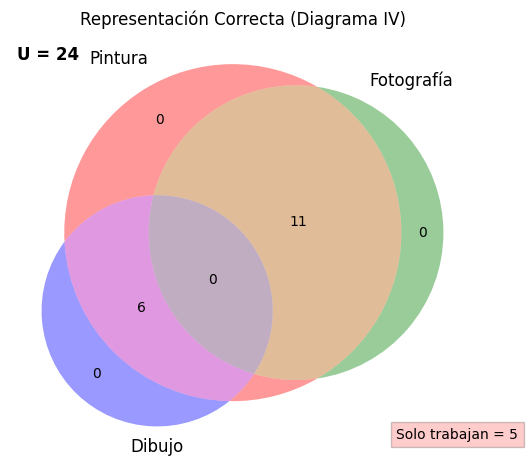

In [45]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

# Datos del Diagrama IV (Supuesto correcto)
# Subsets: (Abc, aBc, ABc, abC, AbC, aBC, ABC) # 
# Donde A=P, B=F, C=D
# En el diagrama IV vemos regiones específicas:
subsets_iv = (0, 0, 11, 0, 6, 2, 0) # Simplificado para el ejemplo

plt.figure(figsize=(6,6))
v = venn3(subsets=subsets_iv, set_labels=('Pintura', 'Fotografía', 'Dibujo'))

# Añadir el universo
plt.text(-0.7, 0.6, "U = 24", fontsize=12, fontweight='bold')
plt.text(0.5, -0.6, "Solo trabajan = 5", fontsize=10, bbox=dict(facecolor='red', alpha=0.2))

plt.title("Representación Correcta (Diagrama IV)")
plt.savefig(r"C:\Users\marco\Downloads\diagrama_venn_trabajo.png")  # Guardar la figura como imagen
plt.show()


### 4. Interactividad Didáctica con `ipywidgets`

Este simulador permite ajustar los valores de las intersecciones para ver cómo afectan al total del universo, permitiendo al estudiante "descubrir" por qué el diagrama IV es el único posible.


In [103]:
import ipywidgets as widgets

def validar_universo(solo_p, solo_f, solo_d, p_f, p_d, f_d, triple, fuera):
    total_estudiantes = solo_p + solo_f + solo_d + p_f + p_d + f_d + triple
    universo = total_estudiantes + fuera
    
    print(f"Total en círculos: {total_estudiantes}")
    print(f"Universo resultante: {universo}")
    
    if universo == 24 and fuera == 5:
        print("✅ ¡ESTA CONFIGURACIÓN ES VÁLIDA!")
    else:
        print("❌ No coincide con los datos del problema (U=24, Fuera=5)")

# Controles para experimentar
widgets.interact(validar_universo, 
                 solo_p=(0,20), solo_f=(0,20), solo_d=(0,10),
                 p_f=(0,11), p_d=(0,10), f_d=(0,10), 
                 triple=(0,5), fuera=widgets.fixed(5))


interactive(children=(IntSlider(value=10, description='solo_p', max=20), IntSlider(value=10, description='solo…

<function __main__.validar_universo(solo_p, solo_f, solo_d, p_f, p_d, f_d, triple, fuera)>

### Resumen de Estrategia
Para problemas de diagramas de Venn con un "Universo", el camino más rápido es la **prueba de la suma**:
$$|U| = |P \cup F \cup D| + |(P \cup F \cup D)^c| = 19 + 5 = 24$$
Si la suma de todas las partes no da el total del grupo, el diagrama se descarta inmediatamente. En este caso, solo el IV cumple la igualdad $19 + 5 = 24$.

# Preguntas 7 y 8

<img src = 'pregunta_7.jpeg' width = 200>

<img src = 'pregunta_8.jpeg' width = 200>

A continuación, presento la resolución detallada de los problemas de lógica y razonamiento de las imágenes proporcionadas, enfocándome en los retos de **Cinemática Gráfica** y **Circuitos Lógicos**, con estrategias para resolverlos en tiempo récord.

---



## 1. Problemas de Cinemática Gráfica (Preguntas 4.5 - 4.7)

### Enunciado
Las gráficas muestran la relación entre la distancia ($d$) a un museo y el tiempo ($t$) para dos personas, $P$ y $Q$. Las personas pueden acercarse (pendiente negativa), alejarse (pendiente positiva) o estar quietas (pendiente cero).



### Estrategia de Resolución Relámpago (< 2 min)
* **Hacia el museo:** La distancia debe disminuir hasta llegar a cero ($d=0$, el eje horizontal).
* **Llegar primero:** Es el punto que toca el eje horizontal más a la izquierda (menor tiempo).
* **Estar parado:** Se representa con una línea completamente horizontal ($d$ no cambia).



### Respuestas
* **4.5:** "P y Q caminan hacia el museo, P estaba más lejos pero llegó primero".
    * **Análisis:** Ambas líneas deben bajar. El punto de inicio de P debe ser más alto (más lejos) que el de Q, pero su intersección con el eje horizontal debe estar antes.
    * **Solución:** **(a) (1)**.
* **4.6:** "P se encontraba parada... Q venía del museo".
    * **Análisis:** P es una línea horizontal. Q empieza en $d=0$ (museo) y su distancia aumenta (se aleja).
    * **Solución:** **(d) (4)**.
* **4.7:** "P y Q tardaron el mismo tiempo... Q se encontraba mas lejos".
    * **Análisis:** Ambas líneas deben bajar y tocar el eje horizontal en el mismo punto de tiempo. El punto inicial de Q debe ser superior al de P.
    * **Solución:** **(c) (3)**.

---



## 2. Problemas de Lógica de Extensiones (Preguntas 4.8 - 4.10)



### Enunciado
Se tienen dos extensiones, A y B. La extensión B se conecta a la conexión 3 de la extensión A.
* Para que A funcione: Fuente principal con corriente + A en posición ON.
* Para que B funcione: Conexión 3 de A activada + B en posición ON.



### Estrategia de Resolución Relámpago
Es una **cadena de dependencia**. Si el final de la cadena (B) tiene energía, es obligatorio que todos los eslabones anteriores (Fuente y A) tengan energía y estén activados.



### Respuestas
* **4.8:** Única proposición verdadera:
    * **Análisis:** Si B tiene energía (conexión 3 de B activada), significa que recibió energía de A.
    * **Solución:** **(d)** "Si la conexión 3 de B está activada, entonces, necesariamente la conexión 3 de A está activada".
* **4.9:** "Hay dos lámparas y un TV funcionando".
    * **Certeza:** Si hay aparatos encendidos, la energía *debe* haber pasado por la extensión A inicialmente.
    * **Solución:** **(b)** "La extensión A tiene activada su posición ON".
* **4.10:** Afirmación que **no concuerda** lógicamente:
    * **Análisis:** Si a un electrodoméstico le llega corriente y al otro no, habiendo solo un cable conectado, es imposible que la extensión esté en OFF, porque entonces no llegaría corriente a ninguno.
    * **Solución:** **(d)** "Sólo un cable está conectado y la posición de su extensión está activada en OFF".

---



## 3. Implementación Interactiva y Simulación (Python)

Utilizaremos **SymPy** para definir la lógica booleana y **Matplotlib** para visualizar los conceptos de cinemática.

### Lógica de Circuitos con SymPy

$$Energia\_B = Energia\_A \land Conexions\_A \land Interruptor\_B$$


In [ ]:
from sympy import symbols, And

# Definición de variables lógicas
fuente, switch_A, switch_B = symbols('fuente switch_A switch_B')

# La extensión B funciona si y solo si:
energia_A = And(fuente, switch_A)
energia_B = And(energia_A, switch_B)

print(f"Condición para que B funcione: {energia_B}")


### Simulación de Cinemática con Matplotlib e ipywidgets


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets

def plot_cinematica(caso):
    t = np.linspace(0, 10, 100)
    plt.figure(figsize=(6,4))
    
    if caso == '4.5 (Gráfica 1)':
        plt.plot(t, 10 - 2*t, label='P (Más lejos, más rápido)')
        plt.plot(t, 6 - 0.5*t, label='Q (Más cerca, más lento)')
    elif caso == '4.6 (Gráfica 4)':
        plt.axhline(y=5, color='blue', label='P (Parado)')
        plt.plot(t, 0 + t, color='orange', label='Q (Alejándose)')
        
    plt.xlabel('Tiempo'); plt.ylabel('Distancia')
    plt.ylim(0, 12); plt.legend(); plt.grid(True)
    plt.show()

widgets.interact(plot_cinematica, caso=['4.5 (Gráfica 1)', '4.6 (Gráfica 4)'])


### Resumen Didáctico
1.  **Cinemática:** La velocidad es la pendiente de la recta $\Delta d / \Delta t$.
2.  **Lógica:** En sistemas en serie, la falla del origen desactiva todo, pero el funcionamiento del final confirma todo el origen.

# Preguntas 9 y 10 (Tema 1 Análisis del Lenguaje)

<img src = 'preguntas_9_y_10.jpeg' width = 100>

Para resolver las preguntas **1.9** y **1.10** de la imagen `preguntas_9_y_10.jpeg`, debemos aplicar lógica de permutaciones y descarte, basándonos en las reglas establecidas en el juego de los símbolos.

---



### 1. Problema 1.9: Determinación de la Asignación Correcta
**Contexto:** Basado en el juego que comenzó en la imagen anterior, donde en la **Jugada 4** el arreglo $[\bigcirc, \diamond, \square, \bigstar, \triangle]$ arrojó un contador de **2**.



#### **Estrategia Relámpago (< 1 min)**
* En la **Jugada 3**, el arreglo era $[\bigcirc, \diamond, \square, \triangle, \bigstar]$ con contador **0**.
* Al pasar a la **Jugada 4**, se intercambiaron $\triangle$ y $\bigstar$. El contador pasó de **0 a 2**.
* **Deducción Crítica:** Si un solo intercambio de dos piezas subió el contador en 2, significa que **ambas piezas** $(\triangle \text{ y } \bigstar)$ ahora están en su lugar correcto.
    * $\bigstar$ corresponde a **D**.
    * $\triangle$ corresponde a **E**.
* Mirando las opciones de la pregunta 1.9, solo una termina en $\bigstar, \triangle$:
    * (a) $[\bigcirc, \diamond, \square, \bigstar, \triangle]$
* **Respuesta 1.9: (a)**.

---



### 2. Problema 1.10: Análisis de Jugada Posible
**Enunciado:** Un nuevo juego inicia:
1.  **Inicial:** $[\bigstar, \bigcirc, \diamond, \square, \triangle] \rightarrow$ Contador: **0**.
2.  **Jugada 1:** $[\square, \bigcirc, \diamond, \bigstar, \triangle] \rightarrow$ Contador: **2**.



#### **Estrategia de Resolución**
* Del inicio a la Jugada 1, se intercambiaron $\bigstar$ y $\square$.
* Como el contador subió de **0 a 2**, nuevamente concluimos que $\square$ está correcto en **A** y $\bigstar$ está correcto en **D**.
* $\bigcirc, \diamond, \triangle$ permanecieron quietos. Si el contador es 2, significa que **ninguno** de esos tres está en la posición correcta aún.
* Evaluemos la **opción (a)** de la jugada 2: $[\square, \diamond, \bigcirc, \bigstar, \triangle]$.
    * $\square$ (A) y $\bigstar$ (D) ya sabemos que son correctos.
    * Se intercambiaron $\diamond$ y $\bigcirc$. Si antes ambos estaban mal, y ahora el contador sube a **3**, significa que uno de los dos entró en su posición correcta.
* **Respuesta 1.10: (a)**.

---



### 3. Simulación Interactiva y Modelado (Python)

Utilizaremos **SymPy** para manejar las permutaciones y **ipywidgets** para que experimentes con los intercambios.


In [106]:
import ipywidgets as widgets
from sympy.combinatorics import Permutation

# Definimos la solución correcta según nuestra deducción (Problema 1.10)
# A: cuadrado, B: diamante, C: circulo, D: estrella, E: triangulo
SOLUCION = ['cuadrado', 'diamante', 'circulo', 'estrella', 'triangulo']

def calcular_contador(intento):
    return sum(1 for i, j in zip(intento, SOLUCION) if i == j)

def simulador_juego(p1, p2, p3, p4, p5):
    intento = [p1, p2, p3, p4, p5]
    cont = calcular_contador(intento)
    print(f"Arreglo: {intento}")
    print(f"Contador: {cont}")

# Símbolos disponibles
simbolos = ['estrella', 'circulo', 'diamante', 'cuadrado', 'triangulo']

widgets.interact(simulador_juego, 
                 p1=simbolos, p2=simbolos, p3=simbolos, p4=simbolos, p5=simbolos)


interactive(children=(Dropdown(description='p1', options=('estrella', 'circulo', 'diamante', 'cuadrado', 'tria…

<function __main__.simulador_juego(p1, p2, p3, p4, p5)>

### 4. Representación de Datos con Pandas y Seaborn
Para visualizar por qué la opción (a) es la única posible, mapeamos las jugadas.


In [105]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    'Posición': ['A', 'B', 'C', 'D', 'E'],
    'Inicial (Cont: 0)': ['estrella', 'circulo', 'diamante', 'cuadrado', 'triangulo'],
    'Jugada 1 (Cont: 2)': ['cuadrado', 'circulo', 'diamante', 'estrella', 'triangulo'],
    'Solución': ['cuadrado', 'diamante', 'circulo', 'estrella', 'triangulo']
}

df = pd.DataFrame(data)
# Resaltamos las coincidencias con la solución
df 

,Posición,Inicial (Cont: 0),Jugada 1 (Cont: 2),Solución
0,A,estrella,cuadrado,cuadrado
1,B,circulo,circulo,diamante
2,C,diamante,diamante,circulo
3,D,cuadrado,estrella,estrella
4,E,triangulo,triangulo,triangulo


**Resumen de Resultados:**
* **1.9:** La opción **(a)** es la única que mantiene la coherencia con el incremento de +2 del contador tras el intercambio de D y E.
* **1.10:** La opción **(a)** es la única posible porque respeta los dos puntos fijos hallados ($\square$ y $\bigstar$) y propone un incremento lógico tras un intercambio de piezas erróneas.


### Bloque 3: Nivel Avanzado (5 Símbolos, 5 Posiciones)
*Símbolos: {Red, Blue, Green, Yellow, Pink} | Posiciones: {V, W, X, Y, Z}*

11. **Situación:** Inicial: [R, B, G, Y, P] (Cont: 0). J1: [B, R, G, Y, P] (Cont: 0). J2: [R, B, Y, G, P] (Cont: 1).
    * *Pregunta:* ¿Cuál es el único color que podría estar correcto en J2?
12. **Situación:** Inicial: [P, Y, G, B, R] (Cont: 0). J1: [Y, P, G, B, R] (Cont: 0). J2: [P, Y, B, G, R] (Cont: 0). J3: [R, Y, G, B, P] (Cont: 2).
13. **Situación:** Inicial: [G, R, B, P, Y] (Cont: 1). J1: [G, B, R, P, Y] (Cont: 3).
    * *Pregunta:* Si G es V, ¿quiénes son los otros dos aciertos?
14. **Situación:** Inicial: [B, G, Y, R, P] (Cont: 0). J1: [P, B, G, Y, R] (Cont: 0).
    * *Pregunta:* Realice la tabla de doble entrada de descartes.
15. **Situación:** Inicial: [Y, R, P, B, G] (Cont: 0). J1: [G, Y, R, P, B] (Cont: 5).
    * *Pregunta:* ¿Cuál es la rotación aplicada?

---

### Bloque 4: Nivel Experto (Inferencia y Negación)
*Símbolos: {α, β, γ, δ, ε} | Posiciones: {L1, L2, L3, L4, L5}*

16. **Situación:** Inicial: [α, β, γ, δ, ε] (Cont: 0). J1: [β, α, γ, δ, ε] (Cont: 0). J2: [α, β, δ, γ, ε] (Cont: 0).
    * *Pregunta:* ¿Es posible que ε sea L5? Justifique.
17. **Situación:** El contador marca 2 en la J1: [γ, β, α, ε, δ]. En la J2: [γ, δ, α, ε, β] el contador baja a 1.
    * *Pregunta:* ¿Qué símbolo estaba correcto en J1 y se movió en J2?
18. **Situación:** Se sabe que α = L3. Si en [β, γ, α, δ, ε] el contador es 3.
    * *Pregunta:* ¿Cuáles son las otras dos posiciones correctas posibles?
19. **Situación:** Tres jugadas consecutivas con contador 0, moviendo un símbolo diferente cada vez a la posición L1.
    * *Pregunta:* ¿Cómo ayuda esto a identificar el símbolo de L1 por exclusión?
20. **Situación:** Inicial: [ε, δ, γ, β, α] (Cont: 0). J1 intercambia los extremos y el contador sube a 2.
    * *Pregunta:* ¿Cuál es la correspondencia de L1 y L5?

---

### Herramienta de Gestión: Tabla de Doble Entrada
Para cualquiera de estos ejercicios, utiliza este formato en un papel o Excel para resolverlos en segundos:

| | Pos A | Pos B | Pos C | Pos D | Pos E |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Símbolo 1** | | | | | |
| **Símbolo 2** | | | | | |
| **Símbolo 3** | | | | | |
| **Símbolo 4** | | | | | |
| **Símbolo 5** | | | | | |



**Instrucciones de uso:**
1. Cuando el contador sea **0**, pon una **X** en la intersección del símbolo y la posición de esa jugada.
2. Cuando descubras un **OK**, tacha con **X** toda la fila y toda la columna de ese símbolo/posición (ya que la correspondencia es biunívoca).